<a href="https://colab.research.google.com/github/ericnmt/htd-benchmarking/blob/main/notebooks/T800-HT-ML-RAW-Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HT detection proof-of-concept, time-series analysis (T-800) on raw data

Eric Johnson

## Data Preparation

### 1. Install requirements

In [1]:
# Install numpy, matplotlib, scikit-learn, pyod, pandas
%pip install numpy matplotlib scikit-learn combo pyod pandas torch
!rm -rf sample_data
#!mkdir -p src/content/data/
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyod as pyod
import sklearn
import torch
import os

# RUN LOCALLY AT PROJECT ROOT

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Source folder of imported numpy arrays,
# change if uploaded elsewhere
#DATA = "/content/src/content/data/"

# OR sync to drive (change as necessary, keep the /content/drive/MyDrive prefix)
#from google.colab import drive
#drive.mount('/content/drive')
#DATA = "/content/drive/HTD-Datasets/T800/"

DATA = 'data/AES-T800/npy_arrays/'
DATA_PREP_FIGS = 'data/data-prep-figs/'
T800_FIGS = 'data/AES-T800/roc_auc_plots/'
T800_ENCODINGS ='data/AES-T800/npy_encodings/'
T800_DFS = 'data/AES-T800/roc_auc_dataframes/'

# For raw data
T800_FIGS = 'data/AES-T800/RAW_roc_auc_plots/'
T800_DFS = 'data/AES-T800/RAW_roc_auc_dataframes/'

### 1.5 - Intermediate: Run NumPy conversions


Convert the raw data into numpy arrays, using  the ``00_convert.py`` script, upload to the ``content/src/content/data`` path in this notebook.

In [3]:
# Output the name of the numpy array, corresponding properties

files = os.listdir(DATA)

if not files:
  print("No files found, verify that files have been uploaded to the proper path.")

else:
  for file in files:
    X = np.load(DATA + file)
    print(f'{file:12s} shape={X.shape}, dtype={X.dtype}, nan={np.isnan(X).sum()}')

AES-T800+TrojanDisabled_2.npy shape=(10000, 2500), dtype=float32, nan=0
AES-T800+TrojanDisabled_1.npy shape=(10000, 2500), dtype=float32, nan=0
AES-T800+TrojanTriggered_1.npy shape=(10000, 2500), dtype=float32, nan=0
AES-T800+TrojanTriggered_2.npy shape=(10000, 2500), dtype=float32, nan=0


Confirm that `shape= (10000, 2500)`, `dtype=float32`, and `nan=0`. This means the data was properly converted.

### Plot Trace Overlays
This step verifies that indices are consistent across arrays. Here, we test the assumption that the trace index is at the same point in time for every trace.

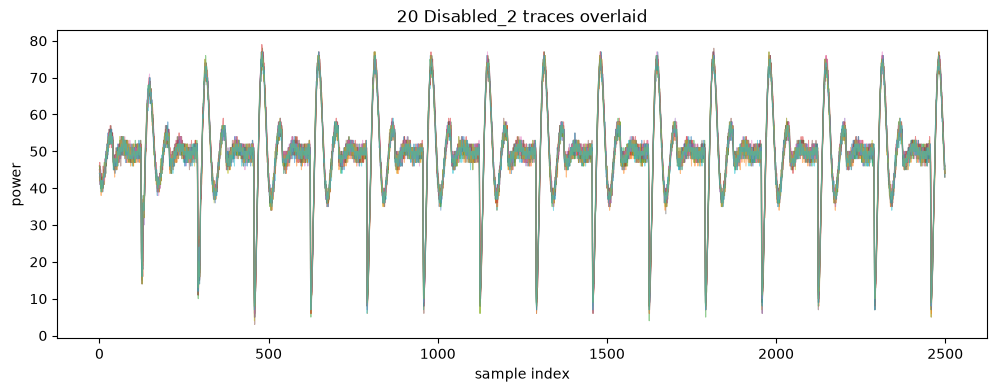

In [4]:
d2 = np.load(f"{DATA}/AES-T800+TrojanDisabled_2.npy")
t2 = np.load(f"{DATA}/AES-T800+TrojanTriggered_2.npy")

plt.figure(figsize=(12,4))
for i in range(20):
  plt.plot(d2[i], alpha=0.5, linewidth=0.7)
plt.title("20 Disabled_2 traces overlaid")
plt.xlabel("sample index"); plt.ylabel("power")
#plt.savefig(f"{DATA_PREP_FIGS}01_alignment.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()

We can conclude that incides and power measurements are consistent across all traces.

#### Mean Comparison Plot: Normal vs Triggered
Here, we see if there are any visual changes made by the Trojan trigger, comparing it to the normal data.

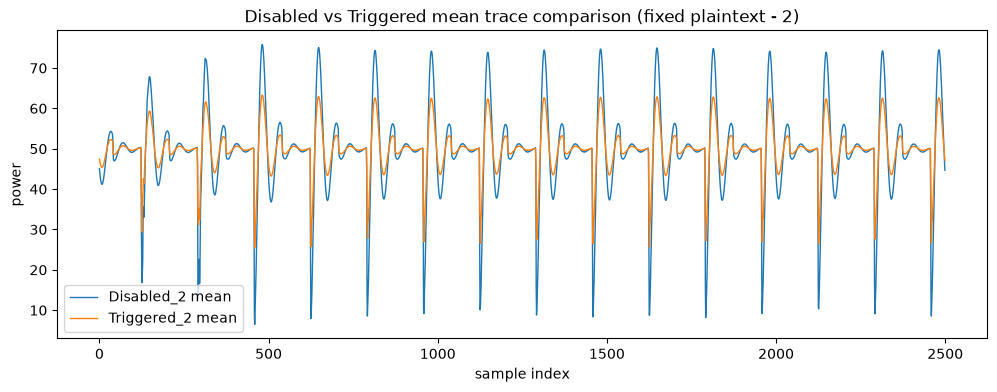

In [5]:
plt.figure(figsize=(12,4))
plt.plot(d2.mean(axis=0), label="Disabled_2 mean", linewidth=1)
plt.plot(t2.mean(axis=0), label="Triggered_2 mean", linewidth=1)
plt.legend()
plt.title("Disabled vs Triggered mean trace comparison (fixed plaintext - 2)")
plt.xlabel("sample index")
plt.ylabel("power")
#plt.savefig(f"{DATA_PREP_FIGS}02_mean_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()

We can conclude that there is a noticable impact on the power output of the circuit when a trojan is active.

#### Difference of Means: Normal vs Triggered
Here, we compare the difference of the mean power of both triggered and normal traces. This highlights the magnitude of the difference between the two signals.

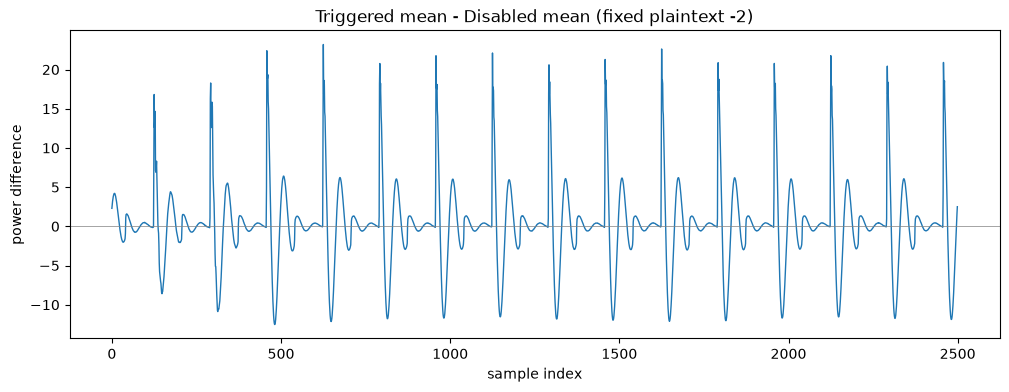

In [6]:
diff = t2.mean(axis=0) - d2.mean(axis=0)
plt.figure(figsize=(12,4))
plt.plot(diff, linewidth=1)
plt.axhline(0, color="gray", linewidth=0.5)
plt.title("Triggered mean - Disabled mean (fixed plaintext -2)")
plt.xlabel("sample index")
plt.ylabel("power difference")
#plt.savefig(f"{DATA_PREP_FIGS}03_diff.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()

#### Per-trace Mean Histogram
This plot is the distribution of the average across the entire trace. While separation betwen power averages is trivial, this may not be the case for other trojan variants (T-600 and T-1600, Golabi et. al).

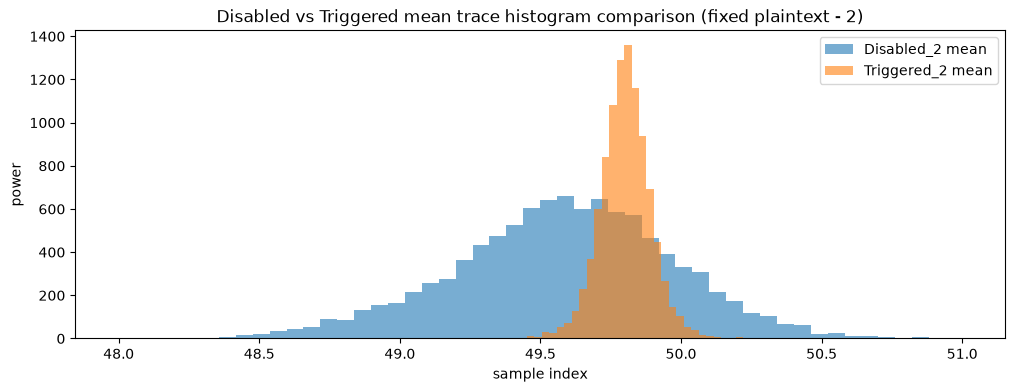

In [7]:
# Load data into d1, t1, d2, t1

d1 = np.load(f"{DATA}/AES-T800+TrojanDisabled_1.npy")
t1 = np.load(f"{DATA}/AES-T800+TrojanTriggered_1.npy")
d2 = np.load(f"{DATA}/AES-T800+TrojanDisabled_2.npy")
t2 = np.load(f"{DATA}/AES-T800+TrojanTriggered_2.npy")

plt.figure(figsize=(12,4))
plt.hist(d2.mean(axis=1), bins=50, alpha=0.6, label = "Disabled_2 mean")
plt.hist(t2.mean(axis=1), bins=50, alpha=0.6, label = "Triggered_2 mean")
plt.legend()
plt.title("Disabled vs Triggered mean trace histogram comparison (fixed plaintext - 2)")
plt.xlabel("sample index")
plt.ylabel("power")
#plt.savefig(f"{DATA_PREP_FIGS}04_hist.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()

#### AUC analysis
This result should be either 0 or 1, showcasing that every anomaly anomaly scores above every normal trace (i.e. there is perfect separation). Note that this is expected for the T-800 data as detector benchmarks scored nearly 99% accuracy in previous work.

In [8]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

# Determine AUC on the first 2000 samples to determine how well anamlous data is separated from normal data
def held_out_auc(disabled, triggered, n_holdout=2000):
  d_test = disabled[-n_holdout:]
  t_test = triggered[-n_holdout:]

  scores = np.concatenate([-d_test.std(axis=1), -t_test.std(axis=1)])
  labels = np.concatenate([np.zeros(len(d_test)), np.ones(len(t_test))])

  return roc_auc_score(labels, scores)

print("AUC, fixed plaintext (_2): ", held_out_auc(d2, t2))
print("AUC, varied plaintext (_1): ", held_out_auc(d1, t1))

AUC, fixed plaintext (_2):  1.0
AUC, varied plaintext (_1):  1.0


### Split Data
Formalize the data splits for training and testing batches. This will be done on fixed plaintext (2) data with 60/40 train/test partitioning.

In [9]:
# 60/40 split on train/test
train_normal = d2[:5000]
test_normal = d2[5000:]
test_anom = t2[:]

print(train_normal.shape, test_normal.shape, test_anom.shape)

(5000, 2500) (5000, 2500) (10000, 2500)


### Fit scaler
This step is essential to ensure that feature selection is optimized, preventing data leakage, and for model preparation.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(train_normal)
# compute the mean/std computer per one of 2500 columns, from train_normal
scaler.fit(train_normal)

train_s = scaler.transform(train_normal)
test_norm_s = scaler.transform(test_normal)
test_anom_s = scaler.transform(test_anom)

In [11]:
print(f'NaNs in train_s: {np.isnan(train_s).sum()}')
print(f'NaNs in test_norm_s: {np.isnan(test_norm_s).sum()}')
print(f'NaNs in test_anom_s: {np.isnan(test_anom_s).sum()}')

NaNs in train_s: 0
NaNs in test_norm_s: 0
NaNs in test_anom_s: 0


If the original and reconstructed plot look similar, then we can conclude that the autoencoder learned, generalized, and reconstructed the features of the original data sufficiently.

### Fit and Detect with ECOD
[Empirical Cumulative disribution-based Outlier Detection](https://pyod.readthedocs.io/en/latest/pyod.models.tabular.html#module-pyod.models.ecod) is a parameter free outlier detection algorithm based on empirical CDF functions.Here, we analyze the model's performance using ROC-AUC and Precision-Recall AUC (PR-AUC) scores. NOTE that score values were negated due to ECOD's native output requiring a sign correction.

ECOD ROC:0.9994, precision @ rank n:0.9986


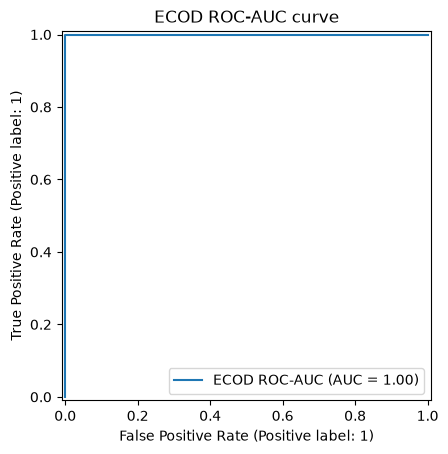

In [ ]:
import pyod as pyod
from pyod.models.ecod import ECOD
from pyod.utils.data import evaluate_print
from sklearn.metrics import roc_auc_score, average_precision_score
# Initialize classifier instance
clf = ECOD()
# Fit/train model on the latent space representation
clf.fit(train_s)

# Compute scores (refer to note)
test_norm_scores = -clf.decision_function(test_norm_s)
test_anom_scores = -clf.decision_function(test_anom_s)

scores = np.concatenate([test_norm_scores, test_anom_scores])
labels = np.concatenate([np.zeros(len(test_norm_scores)), np.ones(len(test_anom_scores))])

# ROC AUC
auc = roc_auc_score(labels, scores)
# Precision/Recall AUC
pr_auc = average_precision_score(labels, scores)

evaluate_print('ECOD', labels, scores)

RocCurveDisplay.from_predictions(labels, scores, name="ECOD ROC-AUC")
plt.title("ECOD ROC-AUC curve")

plt.show()

In [12]:
import pyod as pyod
from pyod.models.ecod import ECOD
from pyod.utils.data import evaluate_print
from sklearn.metrics import roc_auc_score, average_precision_score

SEED = 42

def compute_metrics(name, scores_normal, scores_anom, plot=True):
  scores = np.concatenate([scores_normal, scores_anom])
  labels = np.concatenate([np.zeros(len(scores_normal)), np.ones(len(scores_anom))])

  result = {
      "model": name,
      "roc_auc": roc_auc_score(labels, scores),
      "pr_auc": average_precision_score(labels, scores),
  }

  if plot:
    RocCurveDisplay.from_predictions(labels, scores, name=name)
    plt.title(f"{name} ROC Curve Raw AES-T800")
    plt.savefig(f"{T800_FIGS}raw_{name}_roc_curve", dpi=240, bbox_inches='tight')
    plt.show()
  return result

In [13]:
def evaluate_detector(name, make_detector, Z_train, Z_test_norm, Z_test_anom, invert=False, plot=True):
  clf = make_detector()
  clf.fit(Z_train)
  scores_norm = clf.decision_function(Z_test_norm)
  scores_anom = clf.decision_function(Z_test_anom)
  if invert:
    scores_norm *= -1
    scores_anom *= -1
  result = compute_metrics(name, scores_norm, scores_anom, plot=plot)
  result["inverted"] = invert
  return result

In [ ]:
# IMPORT MODELS HERE
from pyod.models.ecod import ECOD
from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.copod import COPOD

import numpy as np
import pandas as pd

# "name": (lambda: classifier(), Invert(T/F))
detectors = {
    # Baseline Models
    "ECOD": (lambda: ECOD(), False),
    "IForest": (lambda: IForest(random_state=SEED), False),
    "KNN": (lambda: KNN(), False),
    "LOF": (lambda: LOF(), False),
    "COPOD": (lambda: COPOD(), False),
}

results = [
    evaluate_detector(name, make, train_s, test_norm_s, test_anom_s, invert=inv)
    for name, (make, inv) in detectors.items()
]

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(results_df)

### Probabilistic Models

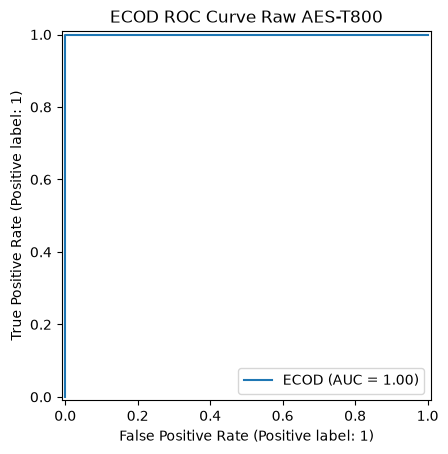

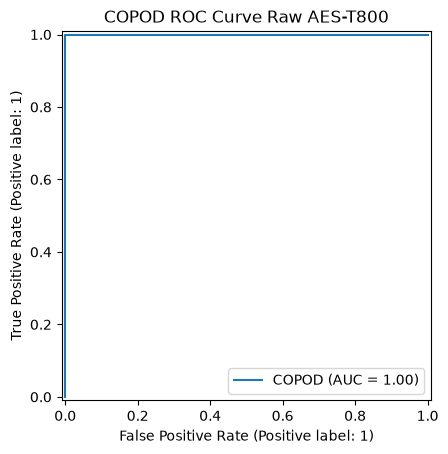

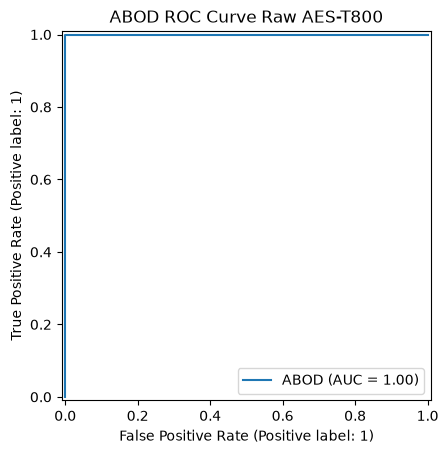

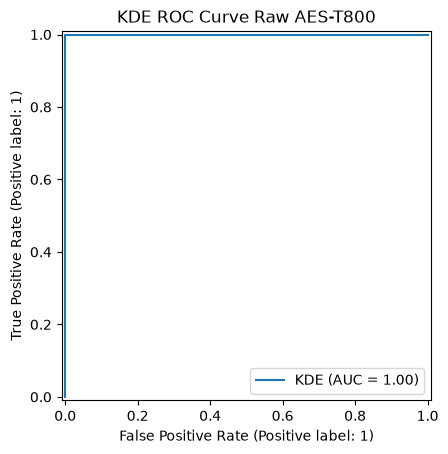

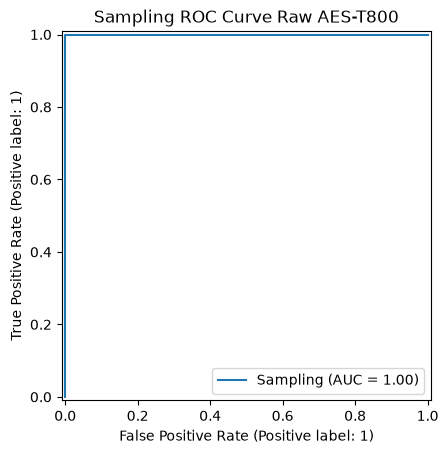

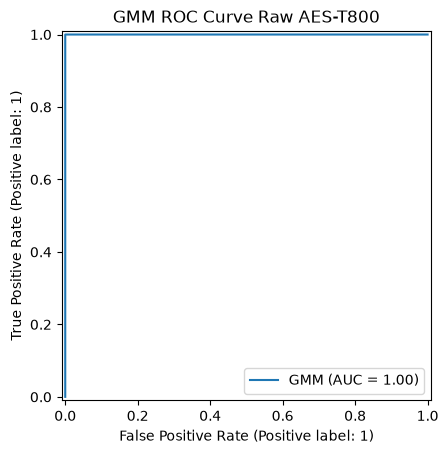

,model,roc_auc,pr_auc,inverted
2,ABOD,1.000000,1.000000,False
3,KDE,1.000000,1.000000,False
4,Sampling,1.000000,1.000000,False
5,GMM,1.000000,1.000000,False
1,COPOD,0.999687,0.999876,True
0,ECOD,0.999418,0.999783,True


In [15]:
# IMPORT MODELS HERE
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.abod import ABOD
from pyod.models.mad import MAD
from pyod.models.sos import SOS
from pyod.models.qmcd import QMCD
from pyod.models.kde import KDE
from pyod.models.sampling import Sampling
from pyod.models.gmm import GMM

import numpy as np
import pandas as pd

# "name": (lambda: classifier(), Invert(T/F))
detectors = {
    # Probabilistic
    "ECOD": (lambda: ECOD(), True),
    "COPOD": (lambda: COPOD(), True),
    "ABOD": (lambda: ABOD(), False),
    # MAD omitted, see below
    # "SOS": (lambda: SOS(), False),
    #"QMCD": (lambda: QMCD(), False),
    "KDE": (lambda: KDE(), False),
    "Sampling": (lambda: Sampling(), False),
    "GMM": (lambda: GMM(), False),
}

results = [
    evaluate_detector(name, make, train_s, test_norm_s, test_anom_s, invert=inv)
    for name, (make, inv) in detectors.items()
]

# results.append(compute_metrics("AE recon error", mse_norm, mse_anom))

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df.to_csv(f"{T800_DFS}01_probabilistic_results.csv", index=True)
display(results_df)

In [ ]:
# MAD
# Omitted for raw sample detection - same results as previous trial.

from pyod.models.mad import MAD

def recon_error(x_s):
  model.eval()
  with torch.no_grad():
    x_t = torch.tensor(x_s, dtype=torch.float32).to(device)
    recon, _ = model(x_t)
  return ((recon.cpu().numpy() - x_s) ** 2).mean(axis=1)

err_train = recon_error(train_s)
err_test_norm = recon_error(test_norm_s)
err_test_anom = recon_error(test_anom_s)

mad = MAD()
mad.fit(err_train.reshape(-1, 1))

s_norm = mad.decision_function(err_test_norm.reshape(-1, 1))
s_anom = mad.decision_function(err_test_anom.reshape(-1, 1))

scores = np.concatenate([s_norm, s_anom])
labels = np.concatenate([np.zeros(len(s_norm)), np.ones(len(s_anom))])

roc_auc = roc_auc_score(labels, scores)
pr_auc = average_precision_score(labels, scores)

mad_result = {
    "model": "MAD on AE recon error",
    "roc_auc": roc_auc,
    "pr_auc": pr_auc,
    "inverted": False
}

print(f"ROC-AUC: {roc_auc} PR-AUC: {pr_auc}")
RocCurveDisplay.from_predictions(labels, scores, name="MAD ROC-AUC")
plt.title("MAD ROC Curve AES-T800")
plt.savefig(f"{T800_FIGS}MAD_roc_curve", dpi=240, bbox_inches='tight')
plt.show()

results_df_mad = pd.DataFrame([mad_result])
results_df_mad.to_csv(f"{T800_DFS}02_mad_results.csv", index=True)
display(results_df_mad)

### Linear Models

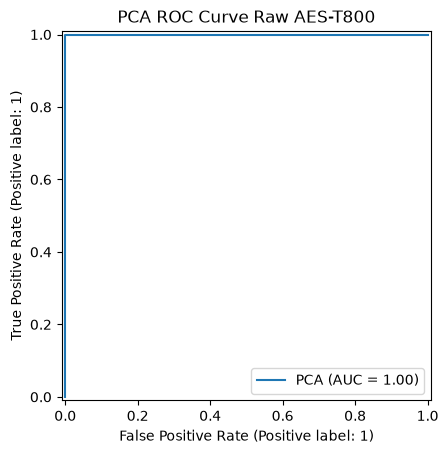

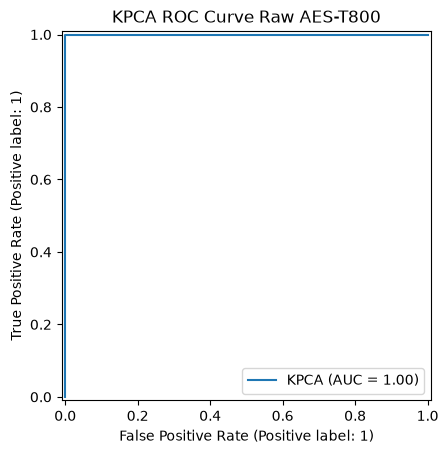

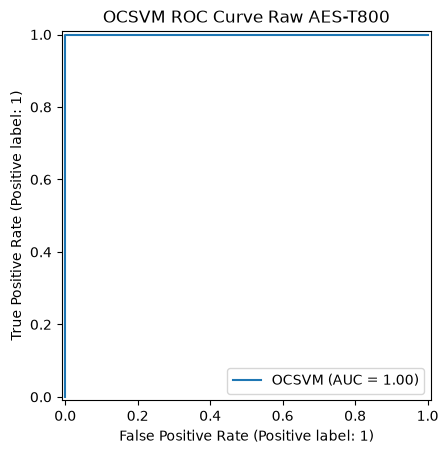

,model,roc_auc,pr_auc,inverted
0,PCA,1.0,1.0,False
1,KPCA,1.0,1.0,False
2,OCSVM,1.0,1.0,False


In [ ]:
from pyod.models.pca import PCA
from pyod.models.kpca import KPCA
from pyod.models.mcd import MCD
from pyod.models.cd import CD
from pyod.models.ocsvm import OCSVM
from pyod.models.lmdd import LMDD

import numpy as np
import pandas as pd

# "name": (lambda: classifier(), Invert(T/F))
detectors = {
    "PCA": (lambda: PCA(), False),
    "KPCA": (lambda: KPCA(), False),
    #"MCD": (lambda: MCD(), False), # Note: needs GPU
    #"CD": (lambda: CD(), False),
    "OCSVM": (lambda: OCSVM(), False),
    #"LMDD": (lambda: LMDD(), False)
}

results = [
    evaluate_detector(name, make, train_s, test_norm_s, test_anom_s, invert=inv)
    for name, (make, inv) in detectors.items()
]

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df.to_csv(f"{T800_DFS}03_linear_results.csv", index=True)
display(results_df)

### Proximity-Based

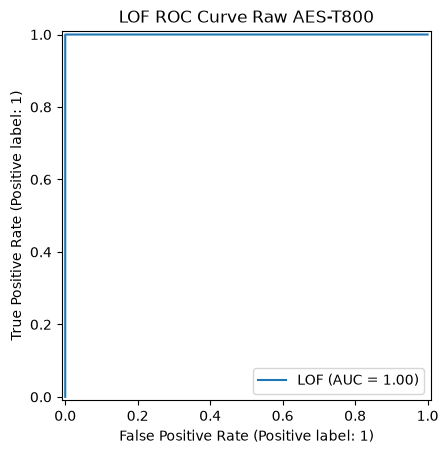

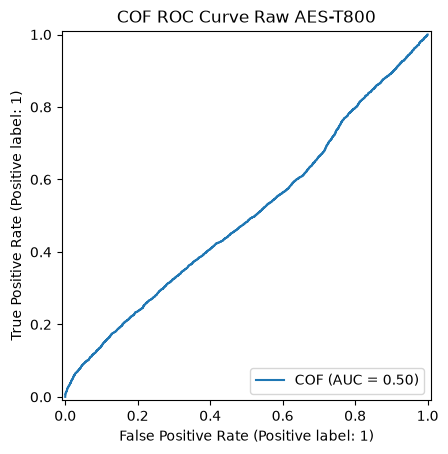

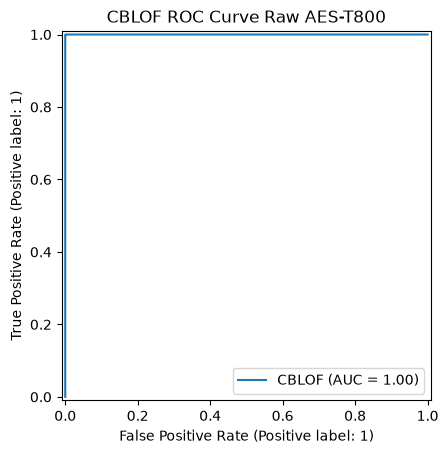

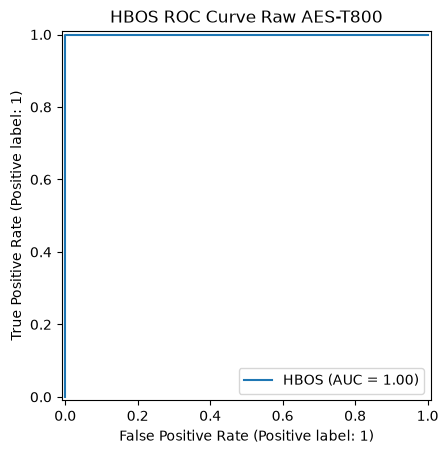

/opt/homebrew/Cellar/jupyterlab/4.6.4/libexec/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


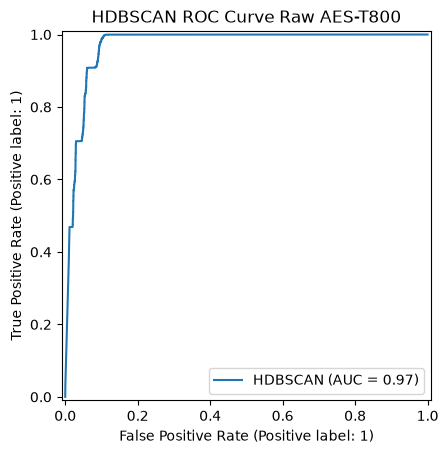

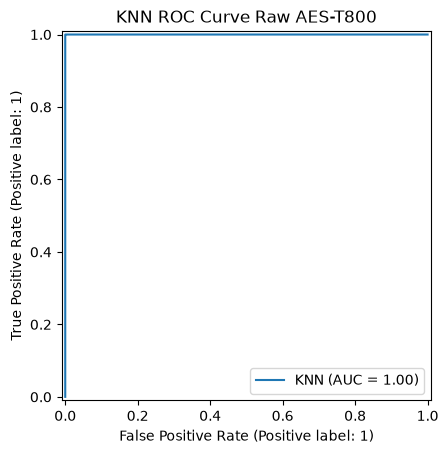

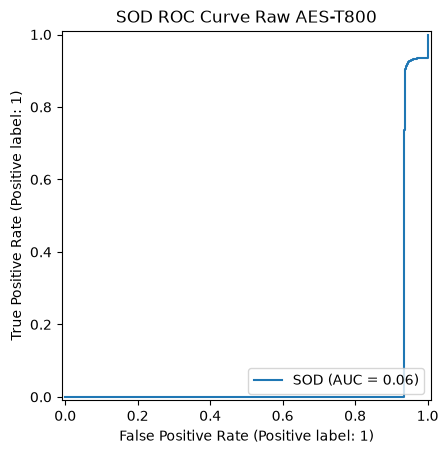

,model,roc_auc,pr_auc,inverted
0,LOF,1.000000,1.000000,False
2,CBLOF,1.000000,1.000000,False
3,HBOS,1.000000,1.000000,False
5,KNN,1.000000,1.000000,False
4,HDBSCAN,0.971803,0.978466,False
1,COF,0.503248,0.693217,False
6,SOD,0.059392,0.463943,False


In [16]:
# IMPORT MODELS HERE
from pyod.models.lof import LOF
from pyod.models.cof import COF
from pyod.models.cblof import CBLOF
from pyod.models.loci import LOCI
from pyod.models.hbos import HBOS
from pyod.models.hdbscan import HDBSCAN
from pyod.models.knn import KNN
from pyod.models.sod import SOD
from pyod.models.rod import ROD

import numpy as np
import pandas as pd

# "name": (lambda: classifier(), Invert(T/F))
detectors = {
    # Proximity-Baed
    "LOF": (lambda: LOF(), False),
    "COF": (lambda: COF(), False),
    "CBLOF": (lambda: CBLOF(random_state=SEED), False),
    #"LOCI": (lambda: LOCI(), False), OMITTED - Timeout on every run
    "HBOS": (lambda: HBOS(), False),
    "HDBSCAN": (lambda: HDBSCAN(), False),
    "KNN": (lambda: KNN(), False),
    "SOD": (lambda: SOD(), False),
    # "ROD": (lambda: ROD(), False) OMITTED - Memory overflow
}

results = [
    evaluate_detector(name, make, train_s, test_norm_s, test_anom_s, invert=inv)
    for name, (make, inv) in detectors.items()
]

# results.append(compute_metrics("AE recon error", mse_norm, mse_anom))

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df.to_csv(f"{T800_DFS}04_proximity_based_results.csv", index=True)
display(results_df)

### Outlier Ensembles

In [ ]:
# LSCP

from pyod.models.lscp import LSCP

# Make the LSCP classifier, consists of:
# KNN, LOF, iForest, and OCSVM models
def make_lscp():
  base = [
      KNN(n_neighbors=10),
      LOF(n_neighbors=10),
      IForest(random_state=SEED),
      OCSVM(),
  ]
  return LSCP(
      detector_list=base,
      local_region_size=30,
      n_bins=len(base),
      random_state=SEED,
  )

detectors["LSCP (KNN, LOF, iForest, OCSVM)"] = (make_lscp, False)

In [ ]:
# SUOD

from pyod.models.suod import SUOD

%pip install suod

# Make the SUOD classifier, consists of:
# KNN (10 neighbors), KNN (20 neighbors), KNN (20 neighbors), LOF (10 neighbors), iForest, OCSVM
def make_suod():
  base = [
      KNN(n_neighbors=10),
      KNN(n_neighbors=20),
      KNN(n_neighbors=20),
      LOF(n_neighbors=10),
      IForest(random_state=SEED),
      OCSVM()
  ]
  return SUOD(
      base_estimators=base,
      combination="average",
      rp_flag_global=False,
      approx_flag_global=False,
      bps_flag=True,
      n_jobs=2,
      verbose=False,
  )

  detectors["SUOD (KNN/LOF/IForest/OCSVM)"] = (make_suod, False)

Note: you may need to restart the kernel to use updated packages.


RandomForestRegressor()



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/jupyterlab/4.6.4/libexec/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 397, in main
    cache[rtype][name] -= 1
    ~~~~~~~~~~~~^^^^^^
KeyError: '/var/folders/_t/cskwn9vx3wgb03d30npfkrt40000gn/T/joblib_memmapping_folder_2831_2e09ba09e0bc4253a8109262182d0e22_8cda355d621d48f98d492fa8f3ebd771/2831-4734020672-e49f0d5aa30341a4850d242959e676b9.pkl'
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:   25.1s finished
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/jupyterlab/4.6.4/libexec/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 397, in main
    cache[rtype][name] -= 1
    ~~~~~~~~~~~~^^^^^^
KeyError: '/var/folders/_t/cskwn9vx3wgb03d30npfkrt40000gn/T/joblib_memmapping_folder_2831_2e09ba09e0bc4253a8109262182d0e22_8cda355d621d48f98d492fa8f3ebd771/2831-473402

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/jupyterlab/4.6.4/libexec/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 397, in main
    cache[rtype][name] -= 1
    ~~~~~~~~~~~~^^^^^^
KeyError: '/var/folders/_t/cskwn9vx3wgb03d30npfkrt40000gn/T/joblib_memmapping_folder_2831_2e09ba09e0bc4253a8109262182d0e22_59360694156143beb272ceeb94c9df12/2831-4734020672-be9f0b6ee5f64e5aba0090fb534e9704.pkl'
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/jupyterlab/4.6.4/libexec/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 397, in main
    cache[rtype][name] -= 1
    ~~~~~~~~~~~~^^^^^^
KeyError: '/var/folders/_t/cskwn9vx3wgb03d30npfkrt40000gn/T/joblib_memmapping_folder_2831_2e09ba09e0bc4253a8109262182d0e22_59360694156143beb272ceeb94c9df12/2831-4734020672-977bd784111948a485fe2f9e51c2d8db.pkl'
Traceback (most recent call

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/jupyterlab/4.6.4/libexec/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 397, in main
    cache[rtype][name] -= 1
    ~~~~~~~~~~~~^^^^^^
KeyError: '/var/folders/_t/cskwn9vx3wgb03d30npfkrt40000gn/T/joblib_memmapping_folder_2831_2e09ba09e0bc4253a8109262182d0e22_d7ee33f03ffd46dfb52a3ed75d4cf478/2831-4734020672-be9f0b6ee5f64e5aba0090fb534e9704.pkl'
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/jupyterlab/4.6.4/libexec/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 397, in main
    cache[rtype][name] -= 1
    ~~~~~~~~~~~~^^^^^^
KeyError: '/var/folders/_t/cskwn9vx3wgb03d30npfkrt40000gn/T/joblib_memmapping_folder_2831_2e09ba09e0bc4253a8109262182d0e22_d7ee33f03ffd46dfb52a3ed75d4cf478/2831-4734020672-977bd784111948a485fe2f9e51c2d8db.pkl'
Traceback (most recent call

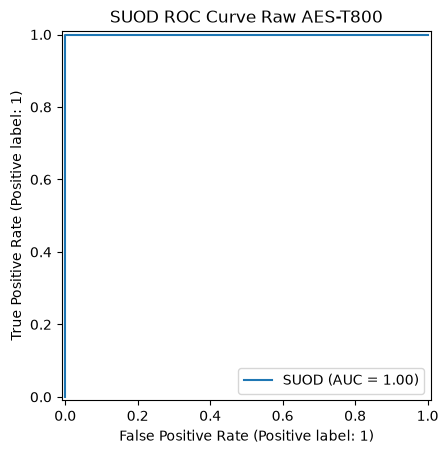

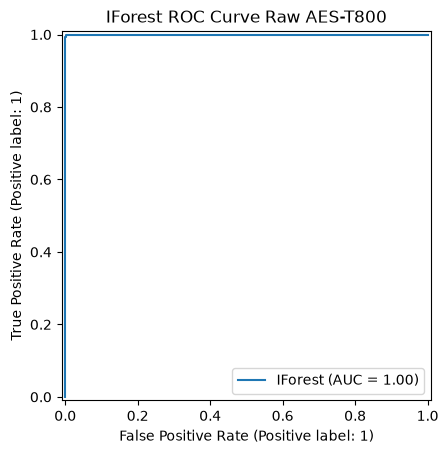

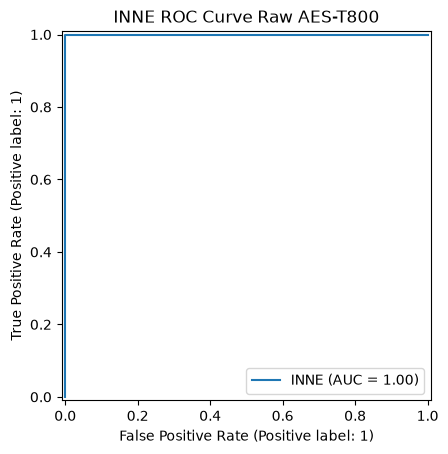

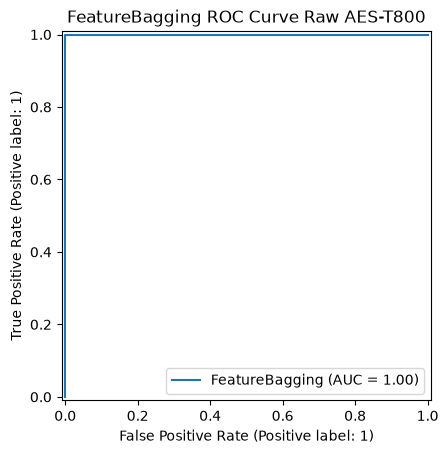

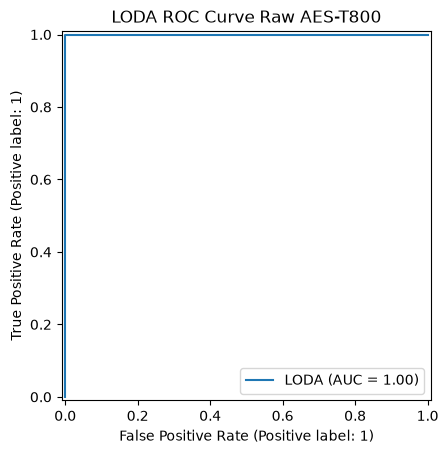

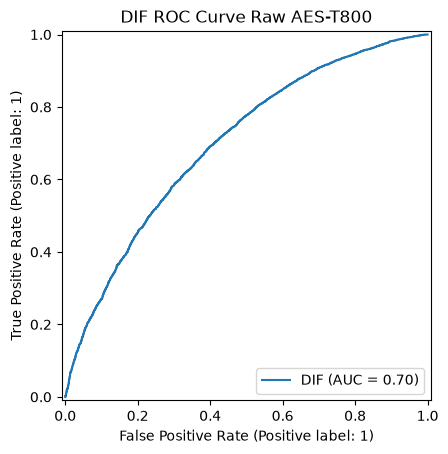

,model,roc_auc,pr_auc,inverted
0,SUOD,1.000000,1.000000,False
2,INNE,1.000000,1.000000,False
3,FeatureBagging,1.000000,1.000000,False
4,LODA,1.000000,1.000000,False
1,IForest,0.999773,0.999857,False
5,DIF,0.699637,0.806146,False


In [ ]:
# IMPORT MODELS HERE
from pyod.models.iforest import IForest
from pyod.models.inne import INNE
from pyod.models.dif import DIF
from pyod.models.feature_bagging import FeatureBagging
from pyod.models.loda import LODA
from pyod.models.ocsvm import OCSVM

import numpy as np
import pandas as pd

# "name": (lambda: classifier(), Invert(T/F))
detectors = {
    # Outlier Ensambles
    "SUOD": (lambda: make_suod(), False),
    #"LSCP": (lambda: make_lscp(), False), Omitted, timeout
    "IForest": (lambda: IForest(random_state=SEED), False),
    "INNE": (lambda: INNE(random_state=SEED), False),
    "FeatureBagging": (lambda: FeatureBagging(random_state=SEED), False),
    "LODA": (lambda: LODA(), False),
    "DIF": (lambda: DIF(random_state=SEED), False),
    # XGBOD Omitted - Not compatible with semi-supervised application
}

results = [
    evaluate_detector(name, make, train_s, test_norm_s, test_anom_s, invert=inv)
    for name, (make, inv) in detectors.items()
]

# results.append(compute_metrics("AE recon error", mse_norm, mse_anom))

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df.to_csv(f"{T800_DFS}05_outlier_ensembles_results.csv", index=True)
display(results_df)

### Neural Networks

In [17]:

# Defines the random seed for reproducable results.
def seeded(builder):
  def make():
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    return builder()
  return make

Note: you may need to restart the kernel to use updated packages.
Epoch 1/100, Loss: 43.78711770474911
Epoch 2/100, Loss: 34.188427582383156
Epoch 3/100, Loss: 26.44653195142746
Epoch 4/100, Loss: 21.12306670099497
Epoch 5/100, Loss: 17.92339626699686
Epoch 6/100, Loss: 15.80959265306592
Epoch 7/100, Loss: 13.794063359498978
Epoch 8/100, Loss: 11.981675069779158
Epoch 9/100, Loss: 10.601712740957737
Epoch 10/100, Loss: 9.72126086242497
Epoch 11/100, Loss: 8.917869910597801
Epoch 12/100, Loss: 8.168603647500277
Epoch 13/100, Loss: 7.516397653147578
Epoch 14/100, Loss: 6.783594047650695
Epoch 15/100, Loss: 5.883873108774424
Epoch 16/100, Loss: 5.334602070041001
Epoch 17/100, Loss: 4.900811051018536
Epoch 18/100, Loss: 4.582434489391744
Epoch 19/100, Loss: 4.226634755032137
Epoch 20/100, Loss: 4.217881703749299
Epoch 21/100, Loss: 3.8805692987516522
Epoch 22/100, Loss: 3.6490030037239194
Epoch 23/100, Loss: 3.56631540087983
Epoch 24/100, Loss: 3.409187044017017
Epoch 25/100, Loss: 3.05967

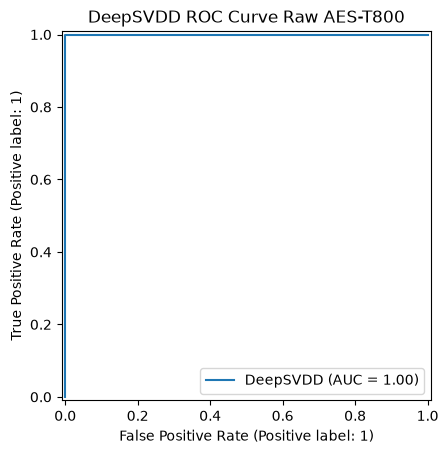

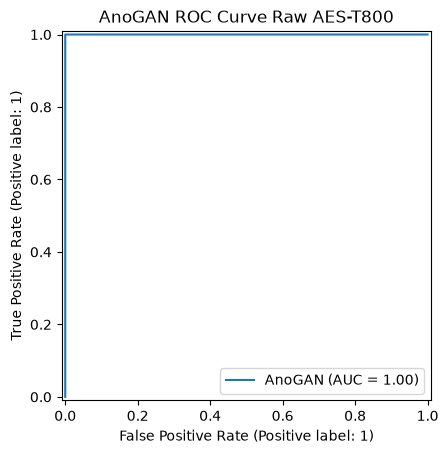

Training: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:06<00:00,  1.58it/s]


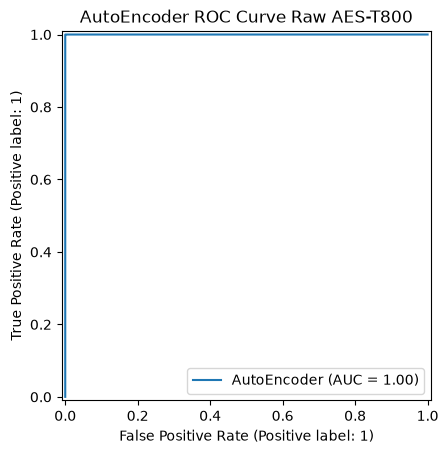

Training: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:09<00:00,  3.10it/s]


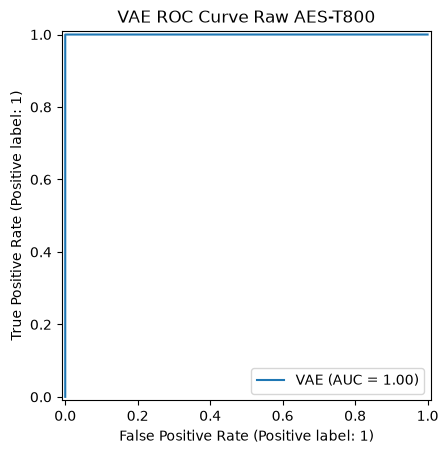

Epoch 10/50, Loss: 2.243728541264868
Epoch 20/50, Loss: 1.721014584325681
Epoch 30/50, Loss: 1.3757938146591187
Epoch 40/50, Loss: 1.0209375934995664
Epoch 50/50, Loss: 0.831419291769623


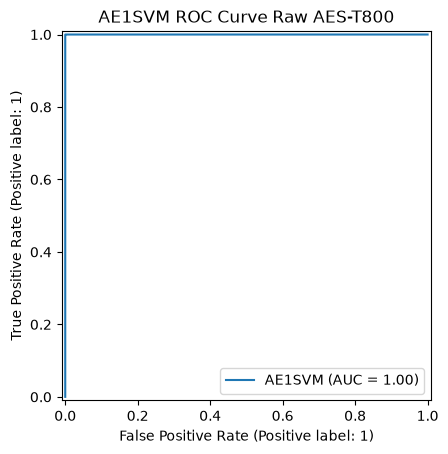

Epoch 1 of 60
Epoch 2 of 60
Epoch 3 of 60
Epoch 4 of 60
Epoch 5 of 60
Epoch 6 of 60
Epoch 7 of 60
Epoch 8 of 60
Epoch 9 of 60
Epoch 10 of 60
Epoch 11 of 60
Epoch 12 of 60
Epoch 13 of 60
Epoch 14 of 60
Epoch 15 of 60
Epoch 16 of 60
Epoch 17 of 60
Epoch 18 of 60
Epoch 19 of 60
Epoch 20 of 60
Epoch 21 of 60
Epoch 22 of 60
Epoch 23 of 60
Epoch 24 of 60
Epoch 25 of 60
Epoch 26 of 60
Epoch 27 of 60
Epoch 28 of 60
Epoch 29 of 60
Epoch 30 of 60
Epoch 31 of 60
Epoch 32 of 60
Epoch 33 of 60
Epoch 34 of 60
Epoch 35 of 60
Epoch 36 of 60
Epoch 37 of 60
Epoch 38 of 60
Epoch 39 of 60
Epoch 40 of 60
Epoch 41 of 60
Epoch 42 of 60
Epoch 43 of 60
Epoch 44 of 60
Epoch 45 of 60
Epoch 46 of 60
Epoch 47 of 60
Epoch 48 of 60
Epoch 49 of 60
Epoch 50 of 60
Epoch 51 of 60
Epoch 52 of 60
Epoch 53 of 60
Epoch 54 of 60
Epoch 55 of 60
Epoch 56 of 60
Epoch 57 of 60
Epoch 58 of 60
Epoch 59 of 60
Epoch 60 of 60


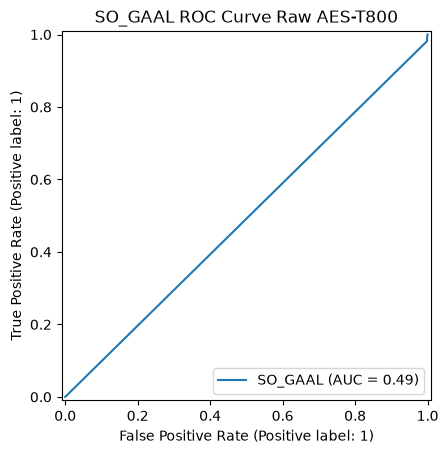

Epoch 1 of 60
Epoch 2 of 60
Epoch 3 of 60
Epoch 4 of 60
Epoch 5 of 60
Epoch 6 of 60
Epoch 7 of 60
Epoch 8 of 60
Epoch 9 of 60
Epoch 10 of 60
Epoch 11 of 60
Epoch 12 of 60
Epoch 13 of 60
Epoch 14 of 60
Epoch 15 of 60
Epoch 16 of 60
Epoch 17 of 60
Epoch 18 of 60
Epoch 19 of 60
Epoch 20 of 60
Epoch 21 of 60
Epoch 22 of 60
Epoch 23 of 60
Epoch 24 of 60
Epoch 25 of 60
Epoch 26 of 60
Epoch 27 of 60
Epoch 28 of 60
Epoch 29 of 60
Epoch 30 of 60
Epoch 31 of 60
Epoch 32 of 60
Epoch 33 of 60
Epoch 34 of 60
Epoch 35 of 60
Epoch 36 of 60
Epoch 37 of 60
Epoch 38 of 60
Epoch 39 of 60
Epoch 40 of 60
Epoch 41 of 60
Epoch 42 of 60
Epoch 43 of 60
Epoch 44 of 60
Epoch 45 of 60
Epoch 46 of 60
Epoch 47 of 60
Epoch 48 of 60
Epoch 49 of 60
Epoch 50 of 60
Epoch 51 of 60
Epoch 52 of 60
Epoch 53 of 60
Epoch 54 of 60
Epoch 55 of 60
Epoch 56 of 60
Epoch 57 of 60
Epoch 58 of 60
Epoch 59 of 60
Epoch 60 of 60


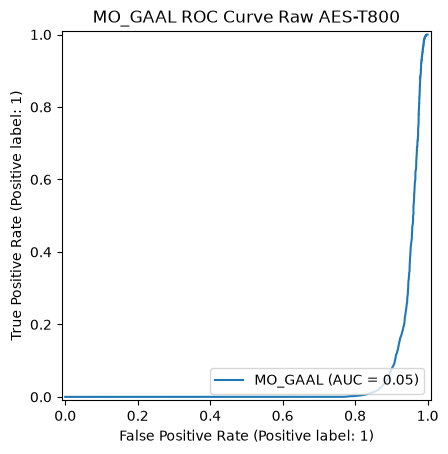

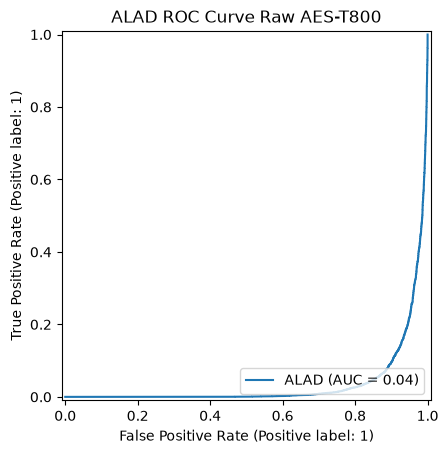

,model,roc_auc,pr_auc,inverted
1,AnoGAN,1.000000,1.000000,False
2,AutoEncoder,1.000000,1.000000,False
4,AE1SVM,1.000000,1.000000,False
3,VAE,1.000000,1.000000,False
0,DeepSVDD,1.000000,1.000000,False
5,SO_GAAL,0.491656,0.662963,False
6,MO_GAAL,0.047836,0.460333,False
7,ALAD,0.036743,0.456214,False


In [19]:
%pip install tqdm

from pyod.models.deep_svdd import DeepSVDD
from pyod.models.auto_encoder import AutoEncoder as PyODAutoEncoder
from pyod.models.vae import VAE
from pyod.models.anogan import AnoGAN
from pyod.models.ae1svm import AE1SVM
from pyod.models.so_gaal import SO_GAAL
from pyod.models.mo_gaal import MO_GAAL
from pyod.models.alad import ALAD
from pyod.models.lunar import LUNAR

N_LATENT = train_s.shape[1]

neural = {
    # Neural Network Models
    "DeepSVDD": (seeded(lambda: DeepSVDD(n_features=N_LATENT, random_state=SEED)), False),
    "AnoGAN": (seeded(lambda: AnoGAN(epochs=20)), False),
    "AutoEncoder": (seeded(lambda: PyODAutoEncoder(hidden_neuron_list=[512,128,32], random_state=SEED)), False),
    "VAE": (seeded(lambda: VAE(encoder_neuron_list=[512,128,32], decoder_neuron_list=[8, 16], latent_dim=4, random_state=SEED)), False),
    "AE1SVM": (seeded(lambda: AE1SVM()), False),
    "SO_GAAL": (seeded(lambda: SO_GAAL()), False),
    "MO_GAAL": (seeded(lambda: MO_GAAL()), False),
    "ALAD": (seeded(lambda: ALAD()), False),
}

neural_results = [
    evaluate_detector(name, make, train_s, test_norm_s, test_anom_s, invert=inv)
    for name, (make, inv) in neural.items()
]

results_df = pd.DataFrame(neural_results).sort_values("roc_auc", ascending=False)
results_df.to_csv(f"{T800_DFS}06_neural_network_results.csv", index=True)
display(results_df)

### Time-Series Outlier Detection Algorithms

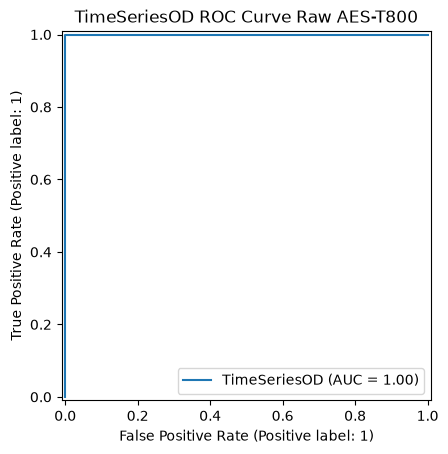

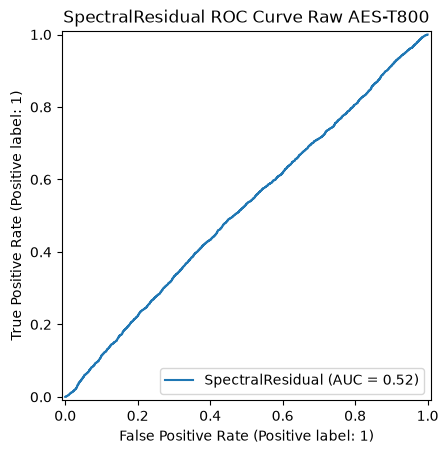

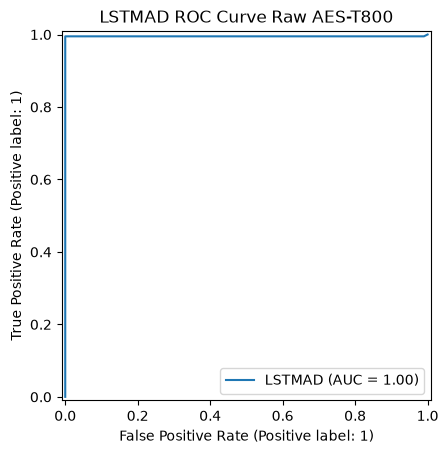

,model,roc_auc,pr_auc,inverted
0,TimeSeriesOD,1.000000,1.000000,False
2,LSTMAD,0.995025,0.998333,False
1,SpectralResidual,0.518977,0.676493,False


In [ ]:
from pyod.models.ts_od import TimeSeriesOD
from pyod.models.ts_spectral_residual import SpectralResidual
from pyod.models.ts_kshape import KShape
from pyod.models.ts_sand import SAND
from pyod.models.ts_lstm import LSTMAD
from pyod.models.ts_anomaly_transformer import AnomalyTransformer

detectors = {
    # Time Series OD
    "TimeSeriesOD": (lambda: TimeSeriesOD(), False),
    "SpectralResidual": (lambda: SpectralResidual(), False),
    #"KShape": (lambda: KShape(), False), Omitted, timeout
    #"SAND": (lambda: SAND(), False), Omitted, timeout
    "LSTMAD": (lambda: LSTMAD(), False),
}

results = [
    evaluate_detector(name, make, train_s, test_norm_s, test_anom_s, invert=inv)
    for name, (make, inv) in detectors.items()
]

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df.to_csv(f"{T800_DFS}07_time_series_od_results.csv", index=True)
display(results_df)

### Graph-Based Detection Algorithms

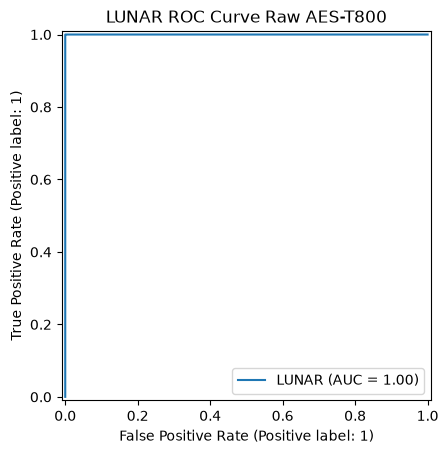

,model,roc_auc,pr_auc,inverted
0,LUNAR,1.0,1.0,False


In [ ]:
from pyod.models.lunar import LUNAR
from pyod.models.rgraph import RGraph
from pyod.models.embedding import EmbeddingOD

detectors = {
    # Graph and embedding based
    "LUNAR": (lambda: LUNAR(), False),
    #"RGraph": (lambda: RGraph(blocksize_test_data=200), False),
}

results = [
    evaluate_detector(name, make, train_s, test_norm_s, test_anom_s, invert=inv)
    for name, (make, inv) in detectors.items()
]

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df.to_csv(f"{T800_DFS}08_graph_based_results.csv", index=True)
display(results_df)

### Evaluate Reconstruction Error
Here, we evaluate if the autoencoder actually learned something useful. Ideal case is 1.0.


In [ ]:
recon_test_norm, _ = model(torch.tensor(test_norm_s, dtype=torch.float32).to(device))
recon_test_anom, _ = model(torch.tensor(test_anom_s, dtype=torch.float32).to(device))
# Compute MSE of test set - norm set (for normal data)
mse_norm = ((recon_test_norm.detach().cpu().numpy() - test_norm_s) ** 2).mean(axis=1)
# Compute MSE of test set - anom set (for abnormal data)
mse_anom = ((recon_test_anom.detach().cpu().numpy() - test_anom_s) ** 2).mean(axis=1)
recon_scores = np.concatenate([mse_norm, mse_anom])
print("Reconstruction AUC:", roc_auc_score(labels, recon_scores))